# Gromacs Tutorial -  Lysozyme (egg white) in water

## Reference
- [GROMACS Tutorials by Prof. Justin A. Lemkul from Virginia Tech](http://www.mdtutorials.com/gmx/)

In [13]:
import os
import time
import shutil
import typing
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import chiral_client 
print(f'chiral client version: {chiral_client.version}')
from chiral_client.app_type import AppType

chiral client version: 0.3.1


In [15]:
# register a user at cloud.chiral.one, get the token api from the page "Profile"
user_email = os.environ['CHIRAL_USER_EMAIL']
token_api = os.environ['CHIRAL_TOKEN_API']
chiral_computing_url = "api.chiral.one:20000"
remote_dir = 'gromacs'
local_dir = 'test_gromacs'
client = chiral_client.Client(user_email, token_api, remote_dir, local_dir, chiral_computing_url)

In [16]:
# setup local and remote storages
project = 'lysozyme'
if os.path.exists(local_dir):
    shutil.rmtree(local_dir)
os.mkdir(local_dir)
os.mkdir(os.path.join(local_dir, project))
client.set_project(project)
client.create_project_remote()
data_dir = f'./data/gromacs/{project}'
    

In [17]:
# copy input files of the tutorials
for input_file in os.listdir(data_dir):
    shutil.copyfile(
        os.path.join(data_dir, input_file),
        os.path.join(client.local_dir, project, input_file)
    )

In [21]:
# create the job script
with open(os.path.join(client.local_dir, project, 'run_1.sh'), 'w') as f:
        f.write('\n'.join([
                f'#!/bin/bash',
                '',
                f'echo 15 |',
                f'gmx pdb2gmx -f 1AKI_clean.pdb -o 1AKI_processed.gro -water spce',
                f'gmx editconf -f 1AKI_processed.gro -o 1AKI_newbox.gro -c -d 1.0 -bt cubic',
                f'gmx solvate -cp 1AKI_newbox.gro -cs spc216.gro -o 1AKI_solv.gro -p topol.top',
                f'gmx grompp -f ions.mdp -c 1AKI_solv.gro -p topol.top -o ions.tpr',
                f'echo 13 |',
                f'gmx genion -s ions.tpr -o 1AKI_solv_ions.gro -p topol.top -pname NA -nname CL -neutral',
                f'gmx grompp -f minim.mdp -c 1AKI_solv_ions.gro -p topol.top -o em.tpr',
                f'gmx mdrun -deffnm em',
                f'echo 10 0 |',
                f'gmx energy -f em.edr -o potential.xvg',
        ]))
        f.close()

In [49]:
# Chiral computation
# upload input files, submit the computation job
# after the job completes, download the output files
#
input_files = [input_file]
output_files = [
    'em.gro',
    'em.tpr',
    'topol.top',
    'posre.itp',
    'potential.xvg'
]
client.upload_directory()
job_id = client.submit_job_script('run_1.sh', [AppType.Gromacs], input_files, output_files, [], [])
assert len(job_id) > 0
client.wait_until_completion(job_id)
client.download_files(output_files)

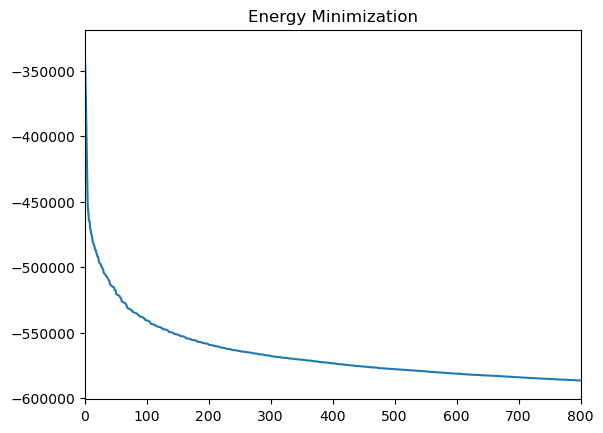

In [50]:
# plot energy
def plot_energy(local_dir: str):
    x,y = np.loadtxt(f'{local_dir}/potential.xvg', comments=['#', '@'], unpack=True)
    plt.plot(x,y)
    plt.title('Energy Minimization')
    plt.xlim((0, 800))
    plt.show()

plot_energy(os.path.join(client.local_dir, project))

In [51]:
# create the job script
with open(os.path.join(client.local_dir, project, 'run_2.sh'), 'w') as f:
        f.write('\n'.join([
                f'#!/bin/bash',
                '',
                f'gmx grompp -f nvt.mdp -c em.gro -r em.gro -p topol.top -o nvt.tpr',
                f'gmx mdrun -deffnm nvt',
                f'echo 16 0 |',
                f'gmx energy -f nvt.edr -o temperature.xvg'
 
        ]))
        f.close()

In [52]:
# chiral computation
input_files = []
output_files = [
    'nvt.gro',
    'nvt.cpt',
    'topol.top',
    'posre.itp',
    'temperature.xvg'
]
client.upload_files(['run_2.sh'])
job_id = client.submit_job_script('run_2.sh', [AppType.Gromacs], input_files, output_files, [], [])
print(f'job {job_id} submitted')
client.wait_until_completion(job_id)
client.download_files(output_files)

job 0n7nw6gofun109tqk7oto23bld3wuyvx submitted


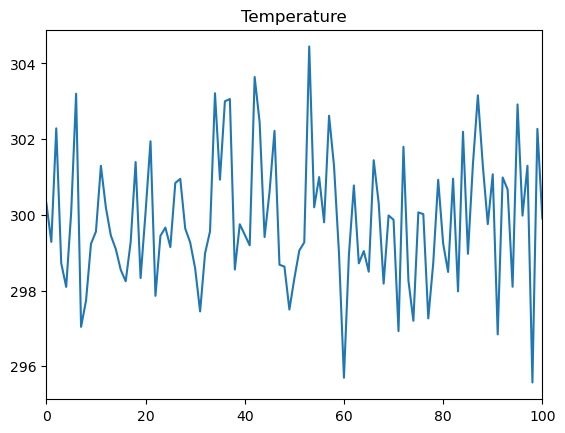

In [53]:
# plot temperature
def plot_temperature(local_dir: str):
    x,y = np.loadtxt(f'{local_dir}/temperature.xvg', comments=['#', '@'], unpack=True)
    plt.plot(x,y)
    plt.title('Temperature')
    plt.xlim((0, 100))
    plt.show()

plot_temperature(os.path.join(client.local_dir, project))

In [44]:
# create the job script for pressure & density
with open(os.path.join(client.local_dir, project, 'run_3.sh'), 'w') as f:
        f.write('\n'.join([
                f'#!/bin/bash',
                '',
                f'gmx grompp -f npt.mdp -c nvt.gro -r nvt.gro -t nvt.cpt -p topol.top -o npt.tpr',
                f'gmx mdrun -deffnm npt',
                f'echo 18 0 |',
                f'gmx energy -f npt.edr -o pressure.xvg',
                f'echo 24 0 |',
                f'gmx energy -f npt.edr -o density.xvg'
 
        ]))
        f.close()

In [45]:
# chiral computation
input_files = []
output_files = [
    'npt.gro',
    'npt.cpt',
    'topol.top',
    'pressure.xvg',
    'density.xvg'
]
client.upload_files(['run_3.sh'])
job_id = client.submit_job_script('run_3.sh', [AppType.Gromacs], input_files, output_files, [], [])
print(f'job {job_id} submitted')
client.wait_until_completion(job_id)
client.download_files(output_files)

job kgj49d6cse5cs1cuxqunhs6il6ox2jkg submitted


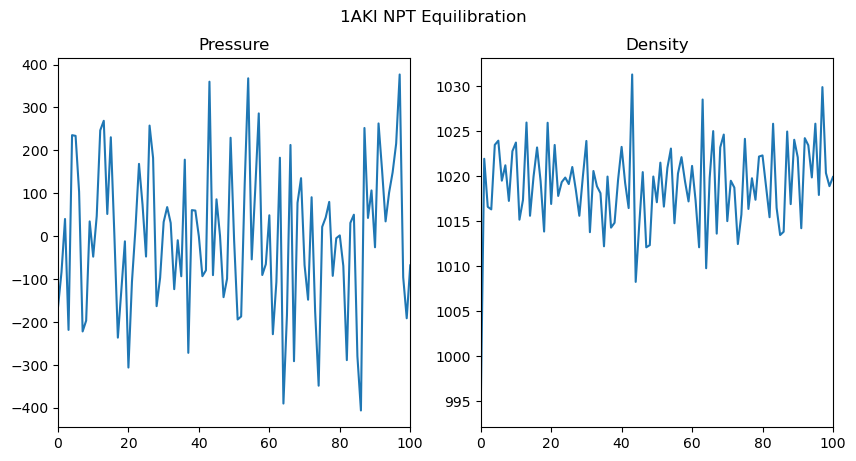

In [46]:
# plot pressure & density

def plot_pressure_density(local_dir: str):
    plt.figure().set_figwidth(10)
    plt.subplot(1, 2, 1) 
    x,y = np.loadtxt(f'{local_dir}/pressure.xvg', comments=['#', '@'], unpack=True)
    plt.plot(x, y)
    plt.title('Pressure')
    plt.suptitle('1AKI NPT Equilibration')
    plt.xlim((0, 100))
    plt.subplot(1, 2, 2) 
    x,y = np.loadtxt(f'{local_dir}/density.xvg', comments=['#', '@'], unpack=True)
    plt.plot(x,y)
    plt.title('Density')
    plt.suptitle('1AKI NPT Equilibration')
    plt.xlim((0, 100))

    plt.show()

plot_pressure_density(os.path.join(client.local_dir, project))

In [54]:
# create the job script for 
with open(os.path.join(client.local_dir, project, 'run_4.sh'), 'w') as f:
        f.write('\n'.join([
                f'#!/bin/bash',
                '',
                f'gmx grompp -f md.mdp -c npt.gro -t npt.cpt -p topol.top -o md_0_1.tpr',
                f'gmx mdrun -deffnm md_0_1 -nb gpu',
                f'echo 1 0 |',
                f'gmx trjconv -s md_0_1.tpr -f md_0_1.xtc -o md_0_1_noPBC.xtc -pbc mol -center',
                f'echo 4 4 |',
                f'gmx rms -s md_0_1.tpr -f md_0_1_noPBC.xtc -o rmsd.xvg -tu ns',
                f'echo 4 4 |',
                f'gmx rms -s em.tpr -f md_0_1_noPBC.xtc -o rmsd_xtal.xvg -tu ns',
                f'echo 1 |',
                f'gmx gyrate -s md_0_1.tpr -f md_0_1_noPBC.xtc -o gyrate.xvg',
        ]))
        f.close()

In [58]:
# chiral computation
input_files = []
output_files = [
    'rmsd.xvg',
    'rmsd_xtal.xvg',
    'gyrate.xvg'
]
client.upload_files(['run_4.sh'])
job_id = client.submit_job_script('run_4.sh', [AppType.Gromacs], input_files, output_files, [], [])
print(f'job {job_id} submitted')
client.wait_until_completion(job_id)
client.download_files(output_files)

job xhkzcpmieftgilyz03hre8lqz8efmkpl submitted


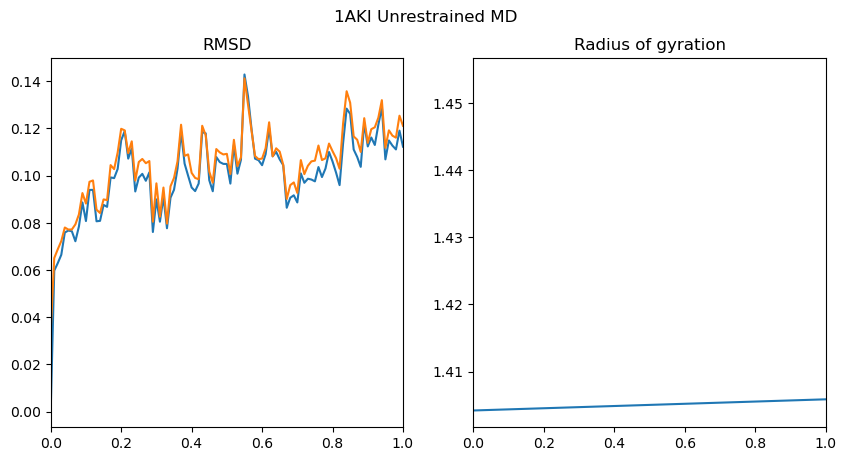

In [59]:
def plot_rmsd_gyration(local_dir: str):
    plt.figure().set_figwidth(10)
    plt.subplot(1, 2, 1) 
    x_1, y_1 = np.loadtxt(f'{local_dir}/rmsd.xvg', comments=['#', '@'], unpack=True)
    x_2, y_2 = np.loadtxt(f'{local_dir}/rmsd_xtal.xvg', comments=['#', '@'], unpack=True)
    plt.plot(x_1, y_1)
    plt.plot(x_2, y_2)
    plt.title('RMSD')
    plt.suptitle('1AKI Backbone')
    plt.xlim((0, 1))
    plt.subplot(1, 2, 2) 
    x_1, y_1, _, _, _ = np.loadtxt(f'{local_dir}/gyrate.xvg', comments=['#', '@'], unpack=True)
    plt.plot(x_1, y_1)
    plt.title('Radius of gyration')
    plt.suptitle('1AKI Unrestrained MD')
    plt.xlim((0, 1))
    plt.show()

plot_rmsd_gyration(os.path.join(client.local_dir, project))